In [1]:
import matplotlib.pyplot as plt
plt.style.use('plots.mplstyle')
%config InlineBackend.figure_format = 'retina'

import numpy as np
from krono import const
import dill as pickle
from scipy.integrate import trapezoid
from importlib import reload

import wind_profiles; reload(wind_profiles)
import geoid; reload(geoid)

<module 'geoid' from '/Users/cmankovi/Library/CloudStorage/OneDrive-JPL/giant-planet-geoids/geoid.py'>

In [2]:
reload(wind_profiles)

phi = np.linspace(-np.pi/2, np.pi/2, 1001)
lat = phi * 180 / np.pi

# get confidence regions for Uranus symmetric rotation profiles
np.random.seed(2025)
omega_many_uranus = np.array([wind_profiles.uranus_omega_tot_interpolant(option='symmetric', randomize=True)(phi) for i in np.arange(1000)])
omega_std_uranus = np.std(omega_many_uranus, axis=0)

# get confidence regions for Neptune voyager rotation profile
# skip pole attenuation because we want true overall uncertainty for this figure
np.random.seed(2025)
omega_many_neptune = np.array([wind_profiles.neptune_omega_tot_interpolant(option='voyager', pole_attenuation=None, randomize=True)(phi) for i in np.arange(1000)])
omega_std_neptune = np.std(omega_many_neptune, axis=0)

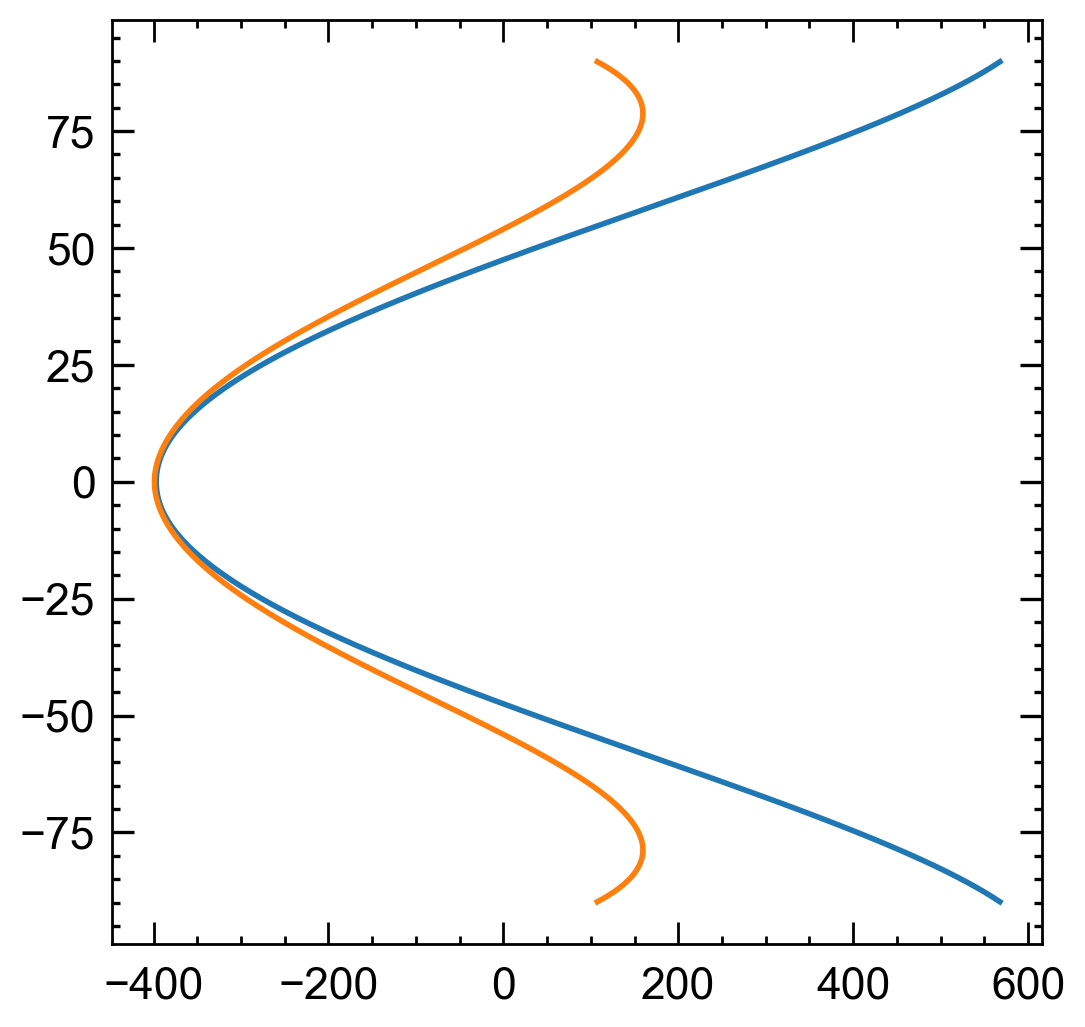

In [5]:
omega = wind_profiles.neptune_omega_tot_interpolant(option='voyager', pole_attenuation=None, randomize=False)

# plt.plot((omega(phi) + omega_std_neptune - np.pi * 2 / 16.11 / 3600), lat)
# plt.plot((omega(phi) - omega_std_neptune - np.pi * 2 / 16.11 / 3600), lat)

rp = 24342e5
re = 24766e5
r_ellipsoid = np.sqrt(np.cos(phi) ** 2 / re ** 2 + np.sin(phi) ** 2 / rp ** 2) ** -1.
r_cylindrical = r_ellipsoid * np.cos(phi)

plt.plot((1e-2 * r_cylindrical * (omega(phi) + omega_std_neptune - np.pi * 2 / 16.11 / 3600))[1:-1], lat[1:-1])
plt.plot((1e-2 * r_cylindrical * (omega(phi) - omega_std_neptune - np.pi * 2 / 16.11 / 3600))[1:-1], lat[1:-1])


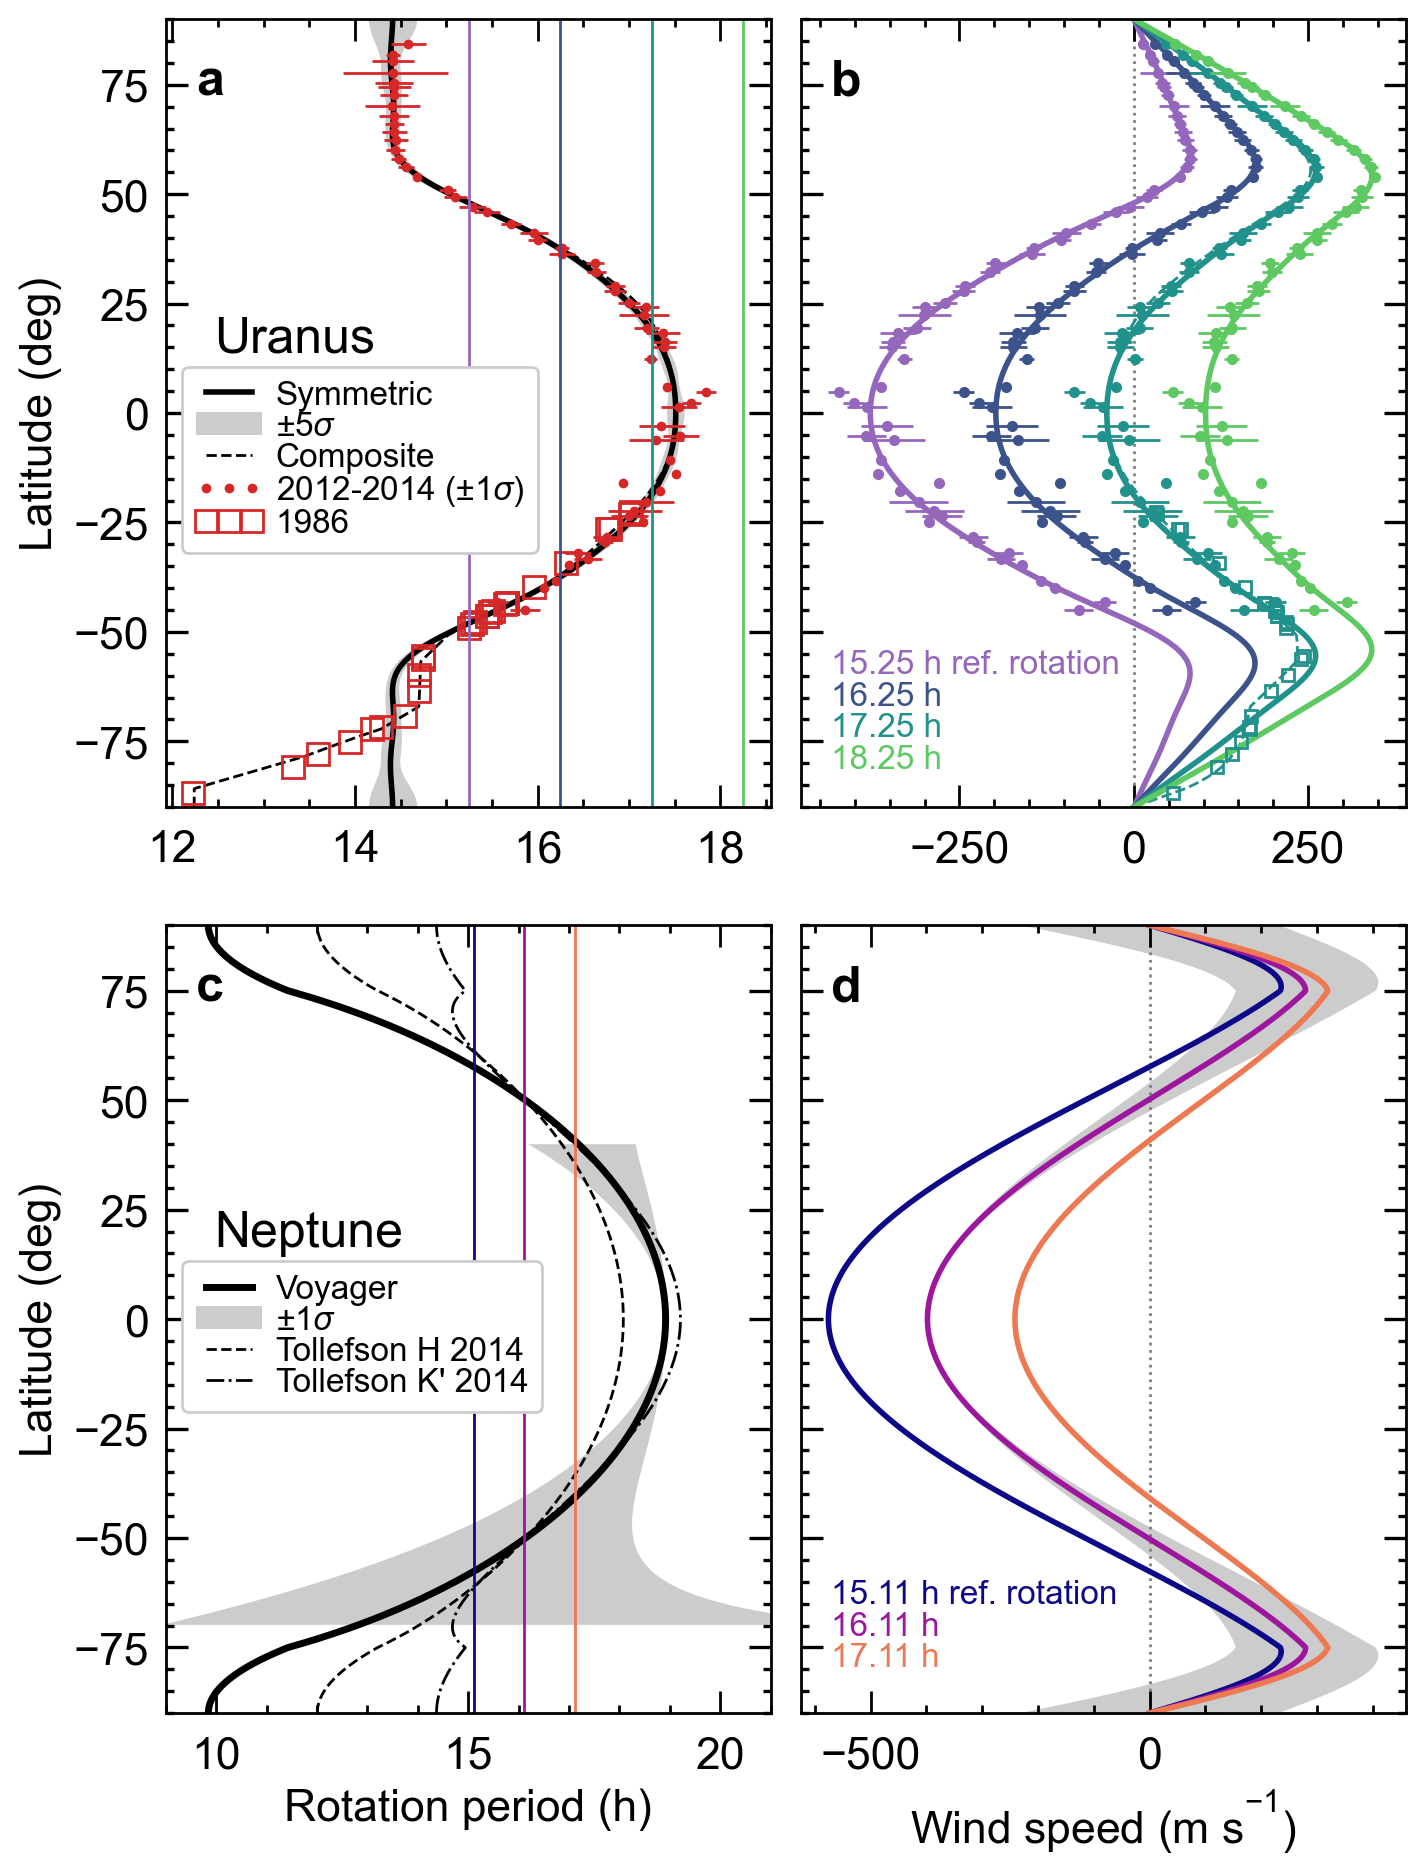

In [6]:
reload(wind_profiles)
from scipy.interpolate import interp1d
fig, ax = plt.subplots(2, 2, figsize=(8, 11), gridspec_kw={'wspace':0.05, 'hspace':0.15})
yl = -90, 90

# uranus
omega = wind_profiles.uranus_omega_tot_interpolant(option='symmetric')
ax[0, 0].plot(np.pi * 2 / omega(phi) / 3600, phi * 180 / np.pi, 'k-', label='Symmetric')
period_symmetric_lo = np.pi * 2 / (omega(phi) - 5 * omega_std_uranus) / 3600
period_symmetric_hi = np.pi * 2 / (omega(phi) + 5 * omega_std_uranus) / 3600
ax[0, 0].fill_betweenx(phi * 180 / np.pi, period_symmetric_lo, period_symmetric_hi, color='k', alpha=0.2, zorder=-1, edgecolor='none', label=r'$\pm5\sigma$')
omega = wind_profiles.uranus_omega_tot_interpolant(option='composite')
ax[0, 0].plot(np.pi * 2 / omega(phi) / 3600, phi * 180 / np.pi, 'k--', lw=1, label='Composite')

data = wind_profiles.get_sromovsky2015_data()
omtot = -data['eastward_drift_rate'] / 3600 * np.pi / 180 + np.pi * 2 / (17.24 * 3600)
omtot_minus = -(data['eastward_drift_rate'] - data['eastward_drift_rate_stddev']) / 3600 * np.pi / 180 + np.pi * 2 / (17.24 * 3600)
omtot_plus  = -(data['eastward_drift_rate'] + data['eastward_drift_rate_stddev']) / 3600 * np.pi / 180 + np.pi * 2 / (17.24 * 3600)
ax[0, 0].plot(np.pi * 2 / omtot / 3600, data['phi'] * 180 / np.pi, 'o', color='tab:red', ms=3, mew=0.5, label=r'2012-2014 ($\pm1\sigma$)')
ax[0, 0].hlines(data['phi'] * 180 / np.pi, np.pi * 2 / omtot_minus / 3600, np.pi * 2 / omtot_plus / 3600, color='tab:red', linewidth=1)

data = wind_profiles.get_karkoschka2015_data()
omtot = np.pi * 2 / data['tracking_period_h'] / 3600
ax[0, 0].plot(np.pi * 2 / omtot / 3600, data['phi'] * 180 / np.pi, 's', color='tab:red', mfc='none', ms=8, label='1986')

# also show composite profile just for baseline rotation
omega = wind_profiles.uranus_omega_tot_interpolant(option='composite')
u_wind = (omega(phi) - np.pi * 2 / 17.25 / 3600) * r_cylindrical
ax[0, 1].plot(u_wind * 1e-2, phi * 180 / np.pi, '--', color=plt.get_cmap()(1. * (2) / 4), lw=1)

# use reference ellipsoid with IAU equatorial/polar radii to get wind speeds from total rotation
rp = 24973e5
re = 25559e5
r_ellipsoid = np.sqrt(np.cos(phi) ** 2 / re ** 2 + np.sin(phi) ** 2 / rp ** 2) ** -1.
r_cylindrical = r_ellipsoid * np.cos(phi)
for ip, p_rot_h in enumerate(17.25 + np.array([-2., -1., 0., 1.])):
    color = 'tab:purple' if ip == 0 else plt.get_cmap()(1. * (ip) / 4)

    omega = wind_profiles.uranus_omega_tot_interpolant(option='symmetric')
    u_wind = (omega(phi) - np.pi * 2 / p_rot_h / 3600) * r_cylindrical
    ax[0, 1].plot(u_wind * 1e-2, phi * 180 / np.pi, color=color)
    ax[0, 0].vlines(p_rot_h, *yl, color=color, linewidth=1, linestyle='-')

    # also plot velocities from data for this rotating frame
    data = wind_profiles.get_sromovsky2015_data()
    data_om_wind = -data['eastward_drift_rate'] / 3600 * np.pi / 180 + np.pi * 2 / (17.24 * 3600) - np.pi * 2 / (p_rot_h * 3600)
    data_om_wind_hi = -(data['eastward_drift_rate'] + data['eastward_drift_rate_stddev']) / 3600 * np.pi / 180 + np.pi * 2 / (17.24 * 3600) - np.pi * 2 / (p_rot_h * 3600)
    data_om_wind_lo = -(data['eastward_drift_rate'] - data['eastward_drift_rate_stddev']) / 3600 * np.pi / 180 + np.pi * 2 / (17.24 * 3600) - np.pi * 2 / (p_rot_h * 3600)
    data_r_ellipsoid = np.sqrt(np.cos(data['phi']) ** 2 / re ** 2 + np.sin(data['phi']) ** 2 / rp ** 2) ** -1.
    data_r_cylindrical = data_r_ellipsoid * np.cos(data['phi'])
    ax[0, 1].plot(1e-2 * data_om_wind * data_r_cylindrical, data['phi'] * 180 / np.pi, 'o', color=color, ms=3)
    ax[0, 1].hlines(data['phi'] * 180 / np.pi, 1e-2 * data_om_wind_lo * data_r_cylindrical, 1e-2 * data_om_wind_hi * data_r_cylindrical, color=color, lw=1)
    # ax[0, 1].text(0.15, 0.95 - 0.04 * ip, f'{p_rot_h:.2f} h', color=color, fontsize=12, ha='left', va='top', transform=ax[0, 1].transAxes)
    if ip == 0:
        label = f'{p_rot_h:.2f} h ref. rotation'
    else:
        label = f'{p_rot_h:.2f} h'
    ax[0, 1].text(0.05, 0.2 - 0.04 * ip, label, color=color, fontsize=12, ha='left', va='top', transform=ax[0, 1].transAxes)

if False: # too cluttered to show uncertainty band
    # for baseline rotation, show +/- 5-sigma regions for speed
    p_rot_h = 17.25
    omega = wind_profiles.uranus_omega_tot_interpolant(option='symmetric')
    u_wind_lo = (omega(phi) - 5. * omega_std - np.pi * 2 / p_rot_h / 3600) * r_cylindrical
    u_wind_hi = (omega(phi) + 5. * omega_std - np.pi * 2 / p_rot_h / 3600) * r_cylindrical
    ax[0, 1].fill_betweenx(phi * 180 / np.pi, 1e-2 * u_wind_lo, 1e-2 * u_wind_hi, color='k', alpha=0.5, zorder=-5, edgecolor='none', lw=0.5)

# also plot velocities from Kark data for System III
data = wind_profiles.get_karkoschka2015_data()
data_om_wind = np.pi * 2 / data['tracking_period_h'] / 3600 - np.pi * 2 / (17.25 * 3600)
data_r_ellipsoid = np.sqrt(np.cos(data['phi']) ** 2 / re ** 2 + np.sin(data['phi']) ** 2 / rp ** 2) ** -1.
data_r_cylindrical = data_r_ellipsoid * np.cos(data['phi'])
ax[0, 1].plot(1e-2 * data_om_wind * data_r_cylindrical, data['phi'] * 180 / np.pi, 's', color=plt.get_cmap()(0.5), mfc='none', ms=4)

ax[0, 0].text(0.08, 0.565, 'Uranus', fontsize=18, ha='left', va='bottom', transform=ax[0, 0].transAxes)
ax[0, 0].legend(fontsize=12, frameon=True, loc=2, bbox_to_anchor=(0, 0.58))

# neptune
wind_options = {
    'voyager':{
        'label':'Voyager',
        'linestyle':'-',
        'linewidth':2.5,
        'color':'k',
    },
    'h-band 2014':{
        'label':'Tollefson H 2014',
        'linestyle':'--',
        'linewidth':1,
        'color':'k',
    },
    'k-band 2014':{
        'label':"Tollefson K' 2014",
        'linestyle':'-.',
        'linewidth':1,
        'color':'k',
    },
}
omega = wind_profiles.neptune_omega_tot_interpolant(option='voyager', pole_attenuation='cosine')
spec = wind_options['voyager']
ax[1, 0].plot(np.pi * 2 / omega(phi) / 3600, lat, **spec)
period_symmetric_lo = np.pi * 2 / (omega(phi) - 5 * omega_std_neptune) / 3600
period_symmetric_hi = np.pi * 2 / (omega(phi) + 5 * omega_std_neptune) / 3600
ax[1, 0].fill_betweenx(lat[np.abs(lat + 15) < 55], period_symmetric_lo[np.abs(lat + 15) < 55], period_symmetric_hi[np.abs(lat + 15) < 55], color='k', alpha=0.2, zorder=-1, edgecolor='none', label=r'$\pm1\sigma$')

omega = wind_profiles.neptune_omega_tot_interpolant(option='h-band 2014', pole_attenuation='cosine')
spec = wind_options['h-band 2014']
ax[1, 0].plot(np.pi * 2 / omega(phi) / 3600, lat, **spec)
omega = wind_profiles.neptune_omega_tot_interpolant(option='k-band 2014', pole_attenuation='cosine')
spec = wind_options['k-band 2014']
ax[1, 0].plot(np.pi * 2 / omega(phi) / 3600, lat, **spec)

ax[1, 0].text(0.08, 0.58, 'Neptune', fontsize=18, ha='left', va='bottom', transform=ax[1, 0].transAxes)
ax[1, 0].legend(fontsize=12, frameon=True, loc=2, bbox_to_anchor=(0, 0.595))

# use reference ellipsoid with IAU equatorial/polar radii to get wind speeds from total rotation
rp = 24342e5
re = 24766e5
r_ellipsoid = np.sqrt(np.cos(phi) ** 2 / re ** 2 + np.sin(phi) ** 2 / rp ** 2) ** -1.
r_cylindrical = r_ellipsoid * np.cos(phi)
for ip, p_rot_h in enumerate(16.11 + np.array([-1., 0., 1.])):
    color = plt.get_cmap('plasma')(1. * (ip) / 3)

    omega = wind_profiles.neptune_omega_tot_interpolant(option='voyager')
    u_wind = (omega(phi) - np.pi * 2 / p_rot_h / 3600) * r_cylindrical
    ax[1, 1].plot(u_wind * 1e-2, phi * 180 / np.pi, color=color)
    # ax[1, 1].text(0.15, 0.95 - 0.04 * ip, f'{p_rot_h:.2f} h', color=color, fontsize=12, ha='left', va='top', transform=ax[1, 1].transAxes)
    if ip == 0:
        label = f'{p_rot_h:.2f} h ref. rotation'
    else:
        label = f'{p_rot_h:.2f} h'
    # label = f'{p_rot_h:.2f} h'
    ax[1, 1].text(0.05, 0.17 - 0.04 * ip, label, color=color, fontsize=12, ha='left', va='top', transform=ax[1, 1].transAxes)
    ax[1, 0].vlines(p_rot_h, *yl, color=color, linewidth=1, linestyle='-')

# ax[1, 1].text(0.05, 0.17, 'Reference rotation:', fontsize=12, ha='left', va='bottom', transform=ax[1, 1].transAxes)

if True: # too cluttered?
    # for baseline rotation, show +/- 5-sigma regions for speed
    p_rot_h = 16.11
    omega = wind_profiles.neptune_omega_tot_interpolant(option='voyager')
    u_wind_lo = (omega(phi) - omega_std_neptune - np.pi * 2 / p_rot_h / 3600) * r_cylindrical
    u_wind_hi = (omega(phi) + omega_std_neptune - np.pi * 2 / p_rot_h / 3600) * r_cylindrical
    ax[1, 1].fill_betweenx(lat, 1e-2 * u_wind_lo, 1e-2 * u_wind_hi, color='k', alpha=0.2, zorder=-5, edgecolor='none')

[z.tick_params(labelleft=False) for z in ax[:, 1]]
ax[1, 0].set_xlabel('Rotation period (h)')
ax[1, 1].set_xlabel('Wind speed (m s$^{-1}$)')
[z.set_ylabel('Latitude (deg)') for z in ax[:, 0]]
[z.set_ylim(*yl) for z in ax.flatten()]
ax[1, 0].set_xlim(9, 21)
[z.vlines(0, *yl, color='tab:grey', linestyle=':', linewidth=1, zorder=-1) for z in ax[:, 1]]

for iax, c in enumerate('abcd'):
    z = ax.flatten()[iax]
    x_offset = 0
    y_offset = 0
    z.text(0.05 + x_offset, 0.95 + y_offset, c, weight='bold', fontsize=18, ha='left', va='top', transform=z.transAxes)

plt.savefig('figures/un_wind_profiles.pdf')